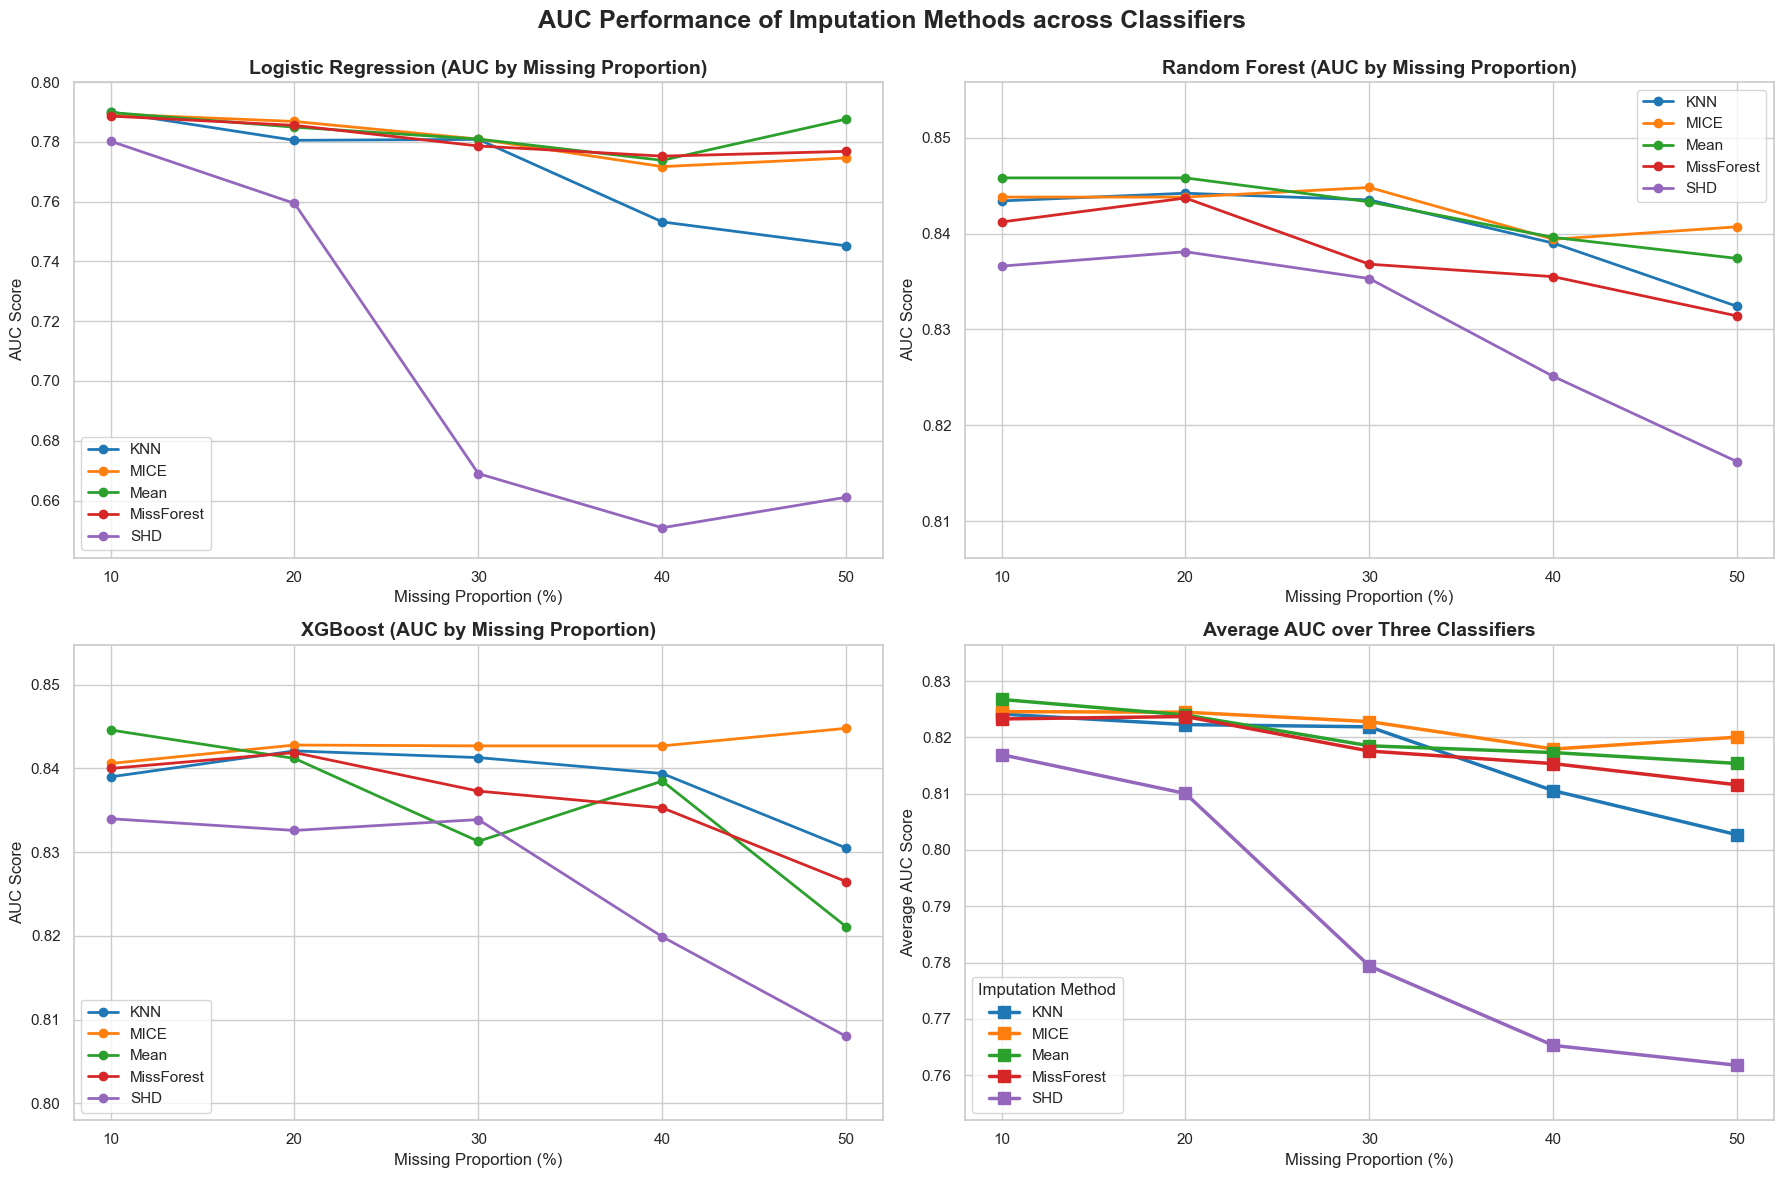

กราฟทั้งหมดถูกบันทึกไว้ที่โฟลเดอร์: auc_charts


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os # เพิ่ม import os สำหรับจัดการโฟลเดอร์

# กำหนดสไตล์ของกราฟให้ดูสะอาดตา
sns.set_theme(style="whitegrid")

# สร้างโฟลเดอร์สำหรับเก็บรูปภาพถ้ายังไม่มี
output_dir = 'auc_charts'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ข้อมูล สัดส่วนที่หายไป (Missing Proportions)
missing_props = [10, 20, 30, 40, 50]
methods = ['KNN', 'MICE', 'Mean', 'MissForest', 'SHD']

# ข้อมูล AUC จากตารางที่สกัดมา
data = {
    'Logistic Regression': {
        'KNN': [0.7900, 0.7805, 0.7808, 0.7532, 0.7452],
        'MICE': [0.7893, 0.7868, 0.7809, 0.7717, 0.7746],
        'Mean': [0.7898, 0.7849, 0.7809, 0.7738, 0.7876],
        'MissForest': [0.7886, 0.7855, 0.7786, 0.7752, 0.7768],
        'SHD': [0.7802, 0.7594, 0.6690, 0.6509, 0.6611]
    },
    'Random Forest': {
        'KNN': [0.8434, 0.8442, 0.8435, 0.8390, 0.8324],
        'MICE': [0.8438, 0.8438, 0.8448, 0.8394, 0.8407],
        'Mean': [0.8458, 0.8458, 0.8433, 0.8396, 0.8374],
        'MissForest': [0.8412, 0.8437, 0.8368, 0.8355, 0.8314],
        'SHD': [0.8366, 0.8381, 0.8353, 0.8251, 0.8162]
    },
    'XGBoost': {
        'KNN': [0.8390, 0.8421, 0.8413, 0.8394, 0.8305],
        'MICE': [0.8406, 0.8428, 0.8427, 0.8427, 0.8448],
        'Mean': [0.8446, 0.8412, 0.8313, 0.8385, 0.8211],
        'MissForest': [0.8400, 0.8419, 0.8373, 0.8353, 0.8265],
        'SHD': [0.8340, 0.8326, 0.8339, 0.8199, 0.8080]
    }
}

# เตรียม Figure ขนาด 2x2 สำหรับใส่ 4 กราฟ
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('AUC Performance of Imputation Methods across Classifiers', fontsize=18, fontweight='bold', y=0.98)

# สีสำหรับแต่ละ Method เพื่อให้ดูสอดคล้องกันทุกกราฟ
colors = {'KNN': '#1f77b4', 'MICE': '#ff7f0e', 'Mean': '#2ca02c', 'MissForest': '#d62728', 'SHD': '#9467bd'}

# สร้างฟังก์ชันสำหรับพล็อตกราฟเส้น
def plot_line_chart(ax, model_name):
    for method in methods:
        ax.plot(missing_props, data[model_name][method], marker='o', linewidth=2, 
                label=method, color=colors[method])
    ax.set_title(f'{model_name} (AUC by Missing Proportion)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Proportion (%)', fontsize=12)
    ax.set_ylabel('AUC Score', fontsize=12)
    ax.set_xticks(missing_props)
    ax.legend()
    # ปรับแกน Y ให้เห็นความแตกต่างชัดเจน แต่หลีกเลี่ยงการบิดเบือนภาพ
    ax.set_ylim(min([min(v) for v in data[model_name].values()]) - 0.01, 
                max([max(v) for v in data[model_name].values()]) + 0.01)
    
    # Save กราฟเดี่ยวแยกออกมา
    fig_single, ax_single = plt.subplots(figsize=(8, 6))
    for method in methods:
        ax_single.plot(missing_props, data[model_name][method], marker='o', linewidth=2, 
                label=method, color=colors[method])
    ax_single.set_title(f'{model_name} (AUC by Missing Proportion)', fontsize=14, fontweight='bold')
    ax_single.set_xlabel('Missing Proportion (%)', fontsize=12)
    ax_single.set_ylabel('AUC Score', fontsize=12)
    ax_single.set_xticks(missing_props)
    ax_single.legend()
    ax_single.set_ylim(min([min(v) for v in data[model_name].values()]) - 0.01, 
                max([max(v) for v in data[model_name].values()]) + 0.01)
    fig_single.savefig(f'{output_dir}/{model_name.replace(" ", "_")}_AUC.png', bbox_inches='tight')
    plt.close(fig_single) # ปิด figure เดี่ยวเพื่อประหยัดหน่วยความจำ

# กราฟที่ 1: Logistic Regression
plot_line_chart(axes[0, 0], 'Logistic Regression')

# กราฟที่ 2: Random Forest
plot_line_chart(axes[0, 1], 'Random Forest')

# กราฟที่ 3: XGBoost
plot_line_chart(axes[1, 0], 'XGBoost')

# ---------------------------------------------------------
# เตรียมข้อมูลสำหรับกราฟ Average AUC over Three classifiers
# คำนวณค่าเฉลี่ย AUC ของแต่ละวิธีจากทั้ง 3 โมเดล ในแต่ละสัดส่วนที่หายไป (10-50%)
avg_over_classifiers = {method: [] for method in methods}
for method in methods:
    for i in range(len(missing_props)):
        # หาค่าเฉลี่ยของ AUC จาก 3 โมเดล ที่ index i (ตาม missing_props)
        avg_val = np.mean([data[model][method][i] for model in data.keys()])
        avg_over_classifiers[method].append(avg_val)

# กราฟที่ 4: Line chart เปรียบเทียบ Average AUC over Three classifiers (อยู่ตำแหน่งมุมขวาล่าง)
ax_line_avg = axes[1, 1]

# สร้างฟังก์ชันสำหรับพล็อตกราฟเส้นเฉลี่ย
def plot_average_line_chart(ax_target):
    for method in methods:
        ax_target.plot(missing_props, avg_over_classifiers[method], marker='s', markersize=8, linewidth=2.5, 
                label=method, color=colors[method])

    ax_target.set_title('Average AUC over Three Classifiers', fontsize=14, fontweight='bold')
    ax_target.set_xlabel('Missing Proportion (%)', fontsize=12)
    ax_target.set_ylabel('Average AUC Score', fontsize=12)
    ax_target.set_xticks(missing_props)
    ax_target.legend(title='Imputation Method')
    
    # ขยายแกน Y เล็กน้อยเพื่อให้เห็นเส้นกราฟชัดเจน
    all_avg_vals = [val for vals in avg_over_classifiers.values() for val in vals]
    min_avg = min(all_avg_vals)
    max_avg = max(all_avg_vals)
    padding = (max_avg - min_avg) * 0.15
    if padding == 0: padding = 0.05
    ax_target.set_ylim(min_avg - padding, max_avg + padding)

# พล็อตลงใน subplot มุมขวาล่าง
plot_average_line_chart(ax_line_avg)

# Save กราฟ Average AUC แยกออกมา
fig_avg, ax_avg_single = plt.subplots(figsize=(8, 6))
plot_average_line_chart(ax_avg_single)
fig_avg.savefig(f'{output_dir}/Average_AUC_over_Three_Classifiers.png', bbox_inches='tight')
plt.close(fig_avg)


# จัดการ Layout ไม่ให้กราฟซ้อนทับกัน
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# บันทึกรูปภาพรวมแบบ 2x2
fig.savefig(f'{output_dir}/All_Charts_Combined.png', bbox_inches='tight')

# แสดงกราฟ
plt.show()
print(f"กราฟทั้งหมดถูกบันทึกไว้ที่โฟลเดอร์: {output_dir}")